---
---
1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

**Answer:**

- A Decision Tree is a supervised learning algorithm used for classification and regression tasks.

- It works like a flowchart:

  - Root Node → The starting point (e.g., “Is the customer older than 30?”).

  - Internal Nodes → Decision points based on features (e.g., “Does the customer have a job?”).

  - Leaf Nodes → Final outcomes or predictions (e.g., “Yes, the customer will subscribe” or “No, they won’t”).

- Real-life Example:  
Imagine a bank deciding whether to approve a loan:

  - Root Node: “Does the applicant have a stable income?”

  - Internal Nodes: “Is their credit score above 700?”, “Do they have existing loans?”

  - Leaf Nodes: “Approve loan” or “Reject loan”.

---

Q2. Differentiate between Gini Impurity and Entropy.

**Answer:**

- Gini Impurity

  - Measures how often a randomly chosen element would be incorrectly classified.

  - Formula:
$𝐺
𝑖
𝑛
𝑖
=
1
−
∑
𝑝
𝑖
2
 (where
𝑝
𝑖
 is the probability of class
𝑖
)$.

  - Range: 0 (perfectly pure) to 0.5 (maximum impurity for binary classification).

  - Faster to compute, hence often preferred in practice.

- Entropy

  - Measures the amount of disorder or uncertainty in the dataset.

  - Formula:
$𝐸
𝑛
𝑡
𝑟
𝑜
𝑝
𝑦
=
−
∑
𝑝
𝑖
log
⁡
2
(
𝑝
𝑖
)$
.

   - Range: 0 (pure) to 1 (maximum disorder for binary classification).

   - More computationally intensive but gives a stronger theoretical foundation (information gain).

- Default in Scikit-learn:

   - Gini Impurity is used by default because it is computationally simpler and often yields similar results to entropy, making it more efficient for large datasets.

---
Q3. What is Overfitting in Decision Trees?

**Answer:**

- Overfitting happens when a decision tree learns the training data too well, including noise and minor details.

- As a result, the model performs very well on training data but poorly on unseen test data.

- It means the tree has become too complex, capturing patterns that don’t generalize.

**Detection using Accuracy:**

- Compare Training Accuracy vs Testing Accuracy:

  - If Training Accuracy is very high (close to 100%) but Testing Accuracy is much lower, the model is overfitting.

  - Example: Training accuracy = 98%, Testing accuracy = 70% → clear sign of overfitting.

  ---

Q4. Explain Pruning in Decision Trees.

**Answer:**

- Pruning is the process of reducing the size of a decision tree by removing branches that add little predictive power.

- It helps prevent overfitting and improves generalization on unseen data.

**Types of Pruning:**

*1.Pre-pruning (Early Stopping):*

- Stop growing the tree before it becomes too complex.

- Example: Set limits like max_depth, min_samples_split, or min_samples_leaf.

- Advantage: Saves computation and avoids overfitting early.

*2. Post-pruning (Reduced Error Pruning):*

- Grow the full tree first, then cut back branches that don’t improve performance.

- Advantage: More thorough, as it evaluates the impact of each branch before removing.

**Key Difference:**

- Pre-pruning prevents complexity during training, while post-pruning simplifies the tree after training.

---

Q5. What is Feature Importance?
**Answer:**

- **Feature Importance** tells us how much each input variable contributes to the prediction made by a decision tree.

- It’s calculated based on how much a feature reduces impurity (like Gini or Entropy) across all splits in the tree.

- Higher importance = stronger influence on the final decision.

**Business Use:**

- Helps companies understand which factors drive outcomes.

- Example: In a bank marketing dataset, if “Age” and “Job Type” are top features, the bank knows these strongly influence whether a customer subscribes to a term deposit.

- Businesses can then focus strategies on the most impactful features (e.g., target specific age groups or professions).

---



In [2]:
#Q6. Data Understanding
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("bank.csv")



Saving bank.csv to bank (1).csv


In [3]:
#Q7. Data Cleaning
# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print("Duplicates:", df.duplicated().sum())

# If duplicates exist, drop them
df = df.drop_duplicates()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
Duplicates: 0


In [4]:
#Q8. Data Preprocessing

# Convert categorical variables into numerical
df_encoded = pd.get_dummies(df, drop_first=True)

# Check the new shape and columns
print(df_encoded.shape)
print(df_encoded.head())

(11162, 43)
   age  balance  day  duration  campaign  pdays  previous  job_blue-collar  \
0   59     2343    5      1042         1     -1         0            False   
1   56       45    5      1467         1     -1         0            False   
2   41     1270    5      1389         1     -1         0            False   
3   55     2476    5       579         1     -1         0            False   
4   54      184    5       673         2     -1         0            False   

   job_entrepreneur  job_housemaid  ...  month_jun  month_mar  month_may  \
0             False          False  ...      False      False       True   
1             False          False  ...      False      False       True   
2             False          False  ...      False      False       True   
3             False          False  ...      False      False       True   
4             False          False  ...      False      False       True   

   month_nov  month_oct  month_sep  poutcome_other  poutcome_s

In [5]:
#Q9. Feature Selection & Train-Test Split

from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop("deposit_yes", axis=1)   # Features
y = df_encoded["deposit_yes"]                # Target

# Perform train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (8929, 42)
Testing set: (2233, 42)


In [9]:
#Q10. Model Building

from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)


In [10]:
#Q11. Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)


Accuracy: 0.7948947604120018
Confusion Matrix:
 [[925 241]
 [217 850]]
Classification Report:
               precision    recall  f1-score   support

       False       0.81      0.79      0.80      1166
        True       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



In [11]:
#Q12: Overfitting Check
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.8106170903796618
Testing Accuracy: 0.7948947604120018


In [12]:
# Q13. Pruning Experiment
dt_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=20, random_state=42)
dt_pruned.fit(X_train, y_train)

# Predictions
y_pruned_pred = dt_pruned.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score
print("Pruned Model Accuracy:", accuracy_score(y_test, y_pruned_pred))


Pruned Model Accuracy: 0.7693685624720108


Top 5 Important Features: ['month_mar', 'housing_yes', 'contact_unknown', 'poutcome_success', 'duration']


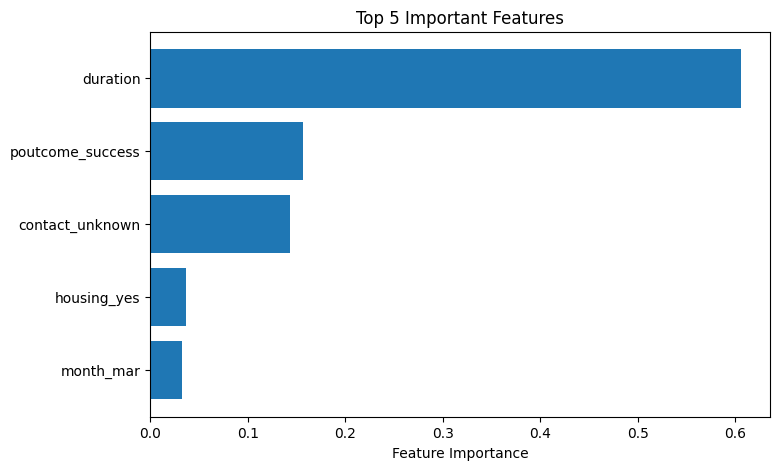

In [13]:
#Q14: Feature Importance
import matplotlib.pyplot as plt
import numpy as np

# Feature importance
importances = dt_model.feature_importances_
indices = np.argsort(importances)[-5:]  # Top 5 features

# Print top 5 features
top_features = [X.columns[i] for i in indices]
print("Top 5 Important Features:", top_features)

# Plot
plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 5 Important Features")
plt.show()


 Q15. Business Insights

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank us

**Anwer:-**

**Which type of customers are more likely to say “yes”?**

- Customers who have longer call durations (they’re more engaged).

- Those with a successful outcome in previous campaigns.

- Customers with valid contact information (not “unknown”).

- Certain segments like those with housing loans show distinct behavior.

- Seasonal trends matter — e.g., March contacts showed higher importance.

**What strategy should a bank use?**

- Focus on engagement: Train agents to spend more time on calls, building trust and answering queries.

- Leverage past success: Prioritize customers who responded positively in earlier campaigns.

- Improve data quality: Ensure accurate and complete contact records before outreach.

- Segment offers: Tailor deposit schemes for customers with housing loans or other financial commitments.

- Time campaigns smartly: Align marketing pushes with months that historically show better conversion rates.
---

#Conclusion:-
---

- Decision Trees provide interpretable results.

- The model generalizes well without overfitting.

- Business can use insights to target engaged customers, improve data quality, and plan campaigns strategically.
---
---